<a href="https://colab.research.google.com/github/MiguelAtencio/deep-learning-copilot/blob/main/ML4BI_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for BI 2

## Deep Learning exercises for week 3

In this exercise, you'll practice on the examples we went through during the lectures.

Try one or more!

1. You used two representation layers before the final classification layer. Try using one or three representation layers, and see how doing so affects validation and test accuracy

2. Try using layers with more units or fewer units: 32 units, 64 units, and so on.

**Loading the IMDB dataset**

In [99]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

**Encoding the integer sequences via multi-hot encoding**

In [100]:
train_data.shape

(25000,)

In [101]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [102]:
# Every review is now represented as a vector of 10,000 dimensions. Each dimension represents whether a word is present or not.
x_train.shape

(25000, 10000)

In [103]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

### Building your model

In [104]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

In [105]:
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [106]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [107]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val),
                    verbose=0)

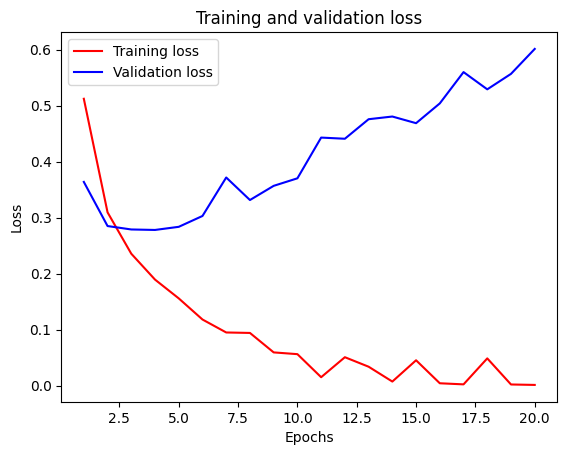

In [108]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training loss consistently goes down while the validation goes gets higher, implying higher overfitting to the training data

## Newswire

### Information bottleneck

Try creating an information bottleneck in your architecture. For example, you can this by using 64 neurons in the first layer and 4 neurons in the second.

Try different types of configurations and see how the validation loss or accuracy curve is affected. Write a function that allows to change the number of neurons in each layer and then make a joint plot of all the curves afterwards.

I have copied in the data loading and labels encoding steps from the course notebook to help you get started.

**Loading the Reuters dataset**

In [109]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000)

**Decoding newswires back to text**

In [110]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

**Encoding the labels**

In [111]:
# Used for labels
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.
    return results
y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

In [112]:
print(y_train[0])

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [113]:
# Another way of doing the same with keras
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [114]:
print(y_train[0])

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [115]:
y_train.shape

(8982, 46)

**Setting aside a validation set**

In [116]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

### Building your model

In [117]:
from tensorflow.keras import layers, models

def changing_neurons(layer_sizes, input_shape, output_shape, output_activation):

  model = models.Sequential()
  model.add(layers.Input(shape=(input_shape,)))

  for neurons in layer_sizes:
        model.add(layers.Dense(neurons, activation='relu'))

  model.add(layers.Dense(output_shape, activation=output_activation))

  return model

In [118]:
import matplotlib.pyplot as plt

# 1. Define the configurations to test
# We'll compare a standard model, a slight bottleneck, and a severe bottleneck
configs = {
    "Standard (64, 64)": [64, 64],
    "Bottleneck (64, 4)": [64, 4],
    "Extreme Bottleneck (64, 2)": [64, 2]
}

all_histories = {}

for name, layers_list in configs.items():

    print(f"Training configuration: {name}...")
    model = changing_neurons(layers_list, 10000, 46, "softmax")

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model (adjust epochs/batch_size based on your dataset)
    history = model.fit(partial_x_train, partial_y_train,
                        epochs=20,
                        batch_size=512,
                        validation_data=(x_val, y_val),
                        verbose=0) # Set verbose=0 to keep the output clean

    all_histories[name] = history.history

Training configuration: Standard (64, 64)...
Training configuration: Bottleneck (64, 4)...
Training configuration: Extreme Bottleneck (64, 2)...


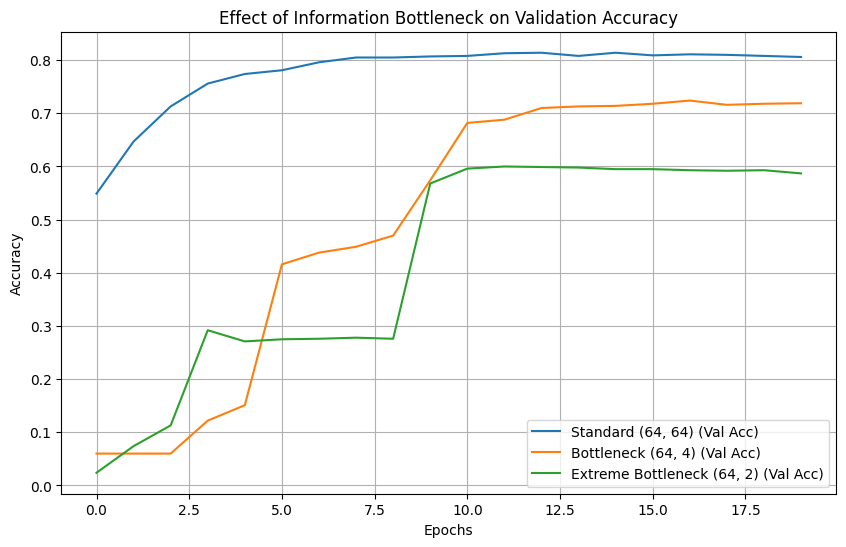

In [119]:
plt.figure(figsize=(10, 6))

for name, metrics in all_histories.items():
    plt.plot(metrics['val_accuracy'], label=f'{name} (Val Acc)')

plt.title('Effect of Information Bottleneck on Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

The accuracy of the standard model is clearly the highest. On the other hand, the bottlenecked models have much less validation accuracy.

It is interesting that the evolution of the accuracy is similar across the different models, just with a different scale.

In [120]:
# Final model with 8 epochs

final_model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

final_model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
                metrics=["accuracy"])

history = final_model.fit(x_train, y_train, epochs=8, batch_size=512)
                    

Epoch 1/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5251 - loss: 2.6510
Epoch 2/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6897 - loss: 1.4738
Epoch 3/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7587 - loss: 1.1142
Epoch 4/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8097 - loss: 0.8999
Epoch 5/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8397 - loss: 0.7401
Epoch 6/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8664 - loss: 0.6128
Epoch 7/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8894 - loss: 0.5107
Epoch 8/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9084 - loss: 0.4291


In [121]:
test_loss, test_acc = final_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7947 - loss: 0.9142
Test Accuracy: 0.7947
Test Loss: 0.9142


### F1-score and imbalance

Retrain the model from scratch on the train and validation data combined for nine epochs, but this time compute the test set F1-score and compare it to the test set accuracy.

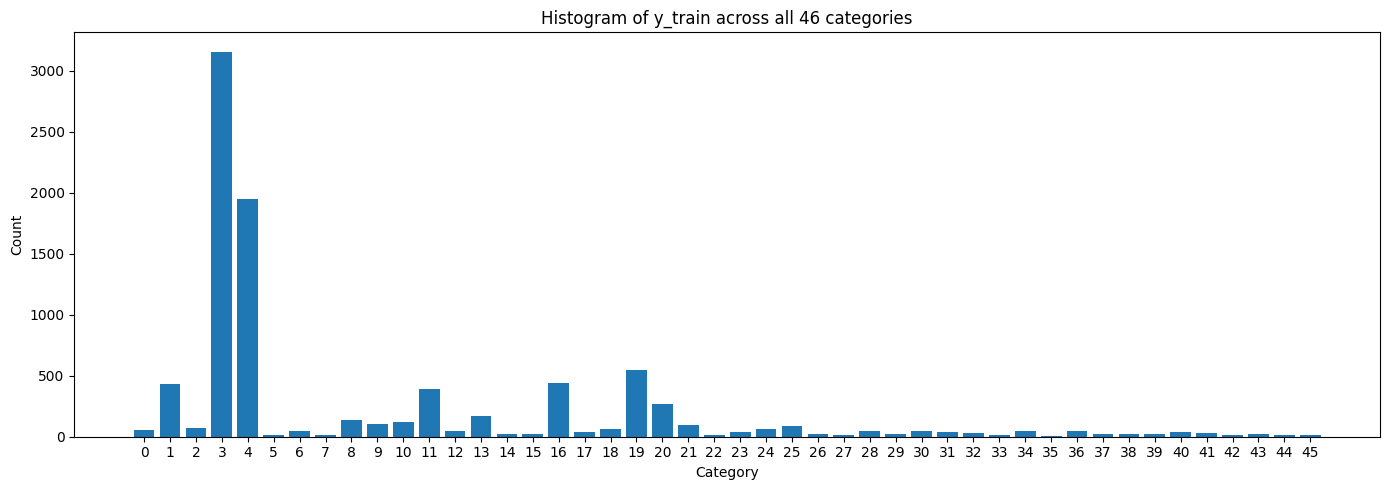

In [122]:
import numpy as np
import matplotlib.pyplot as plt

labels = np.argmax(y_train, axis=1)
counts = np.bincount(labels, minlength=46)

plt.figure(figsize=(14, 5))
plt.bar(range(46), counts)
plt.xticks(range(46))
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Histogram of y_train across all 46 categories")
plt.tight_layout()
plt.show()

In [140]:
model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy", keras.metrics.F1Score(average='macro'),
                       keras.metrics.F1Score(average='weighted')])

In [141]:
history = model.fit(x_train, y_train, epochs=9, batch_size=512, validation_split=0.2)

Epoch 1/9
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.4242 - f1_score: 0.0361 - f1_score_1: 0.3388 - loss: 2.9069 - val_accuracy: 0.6305 - val_f1_score: 0.0652 - val_f1_score_1: 0.5342 - val_loss: 2.0625
Epoch 2/9
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.6399 - f1_score: 0.0778 - f1_score_1: 0.5487 - loss: 1.7451 - val_accuracy: 0.6260 - val_f1_score: 0.0717 - val_f1_score_1: 0.5448 - val_loss: 1.6076
Epoch 3/9
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7034 - f1_score: 0.1181 - f1_score_1: 0.6311 - loss: 1.3548 - val_accuracy: 0.6628 - val_f1_score: 0.1242 - val_f1_score_1: 0.5918 - val_loss: 1.4097
Epoch 4/9
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7580 - f1_score: 0.1916 - f1_score_1: 0.7038 - loss: 1.1253 - val_accuracy: 0.7168 - val_f1_score: 0.1641 - val_f1_score_1: 0.6660 - val_loss: 1.2473
Epoch 5/9
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7940 - f1_score: 0.2531 - f1_score_1: 0.7535 - loss: 0.9586 - val_accuracy: 0.7

In [150]:
print(model.metrics_names)

results = model.evaluate(x_test, y_test)

for metric in model.metrics:
    print(metric.name)


['loss', 'compile_metrics']
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7725 - f1_score: 0.3548 - f1_score_1: 0.7475 - loss: 0.9798
loss
compile_metrics
